In [5]:
print("Hello from the Spark!!!")

Hello from the Spark!!!


In [6]:
import sys
print(sys.executable)

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA GPU detected")

/home/nuspark2/miniconda/envs/ai/bin/python
True
NVIDIA GB10


----
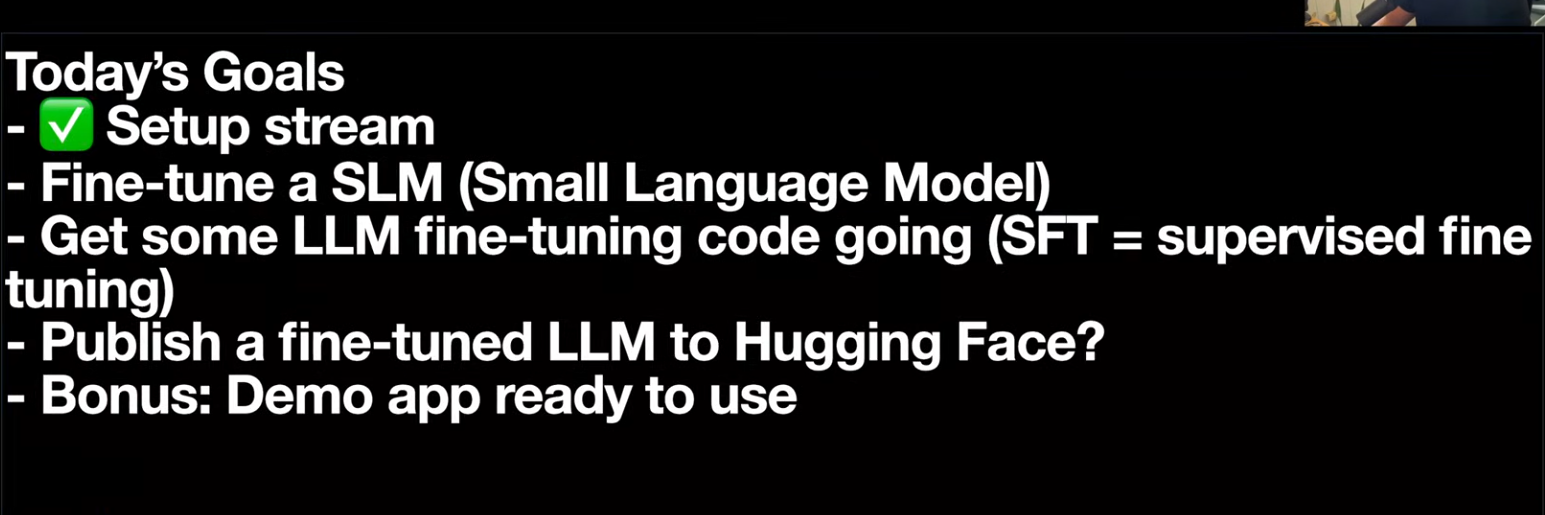

#### Finetuning Model
Learning how to finetune a LLM model, so that we can extract key information using a smaller less capable model.

Using the tutorials from YouTube as basis, 
- https://www.youtube.com/live/M32fJdG3D_A (Part 1)
- https://www.youtube.com/live/zt8t-xT26rA (Part 2)


Objective, make a small model do a specific task (not pay API credits, or leak our data online.)

We are going to fine-tune a model using Supervised Fine-tuning (SFT).

SFT is the simplist I guess, but there are many (written in my Notion notebook), we simply gives samples of input and outputs and let the model learn them.
Given the model is quite capable, we simple need a dataset, finetune a capable model (tutorial used a 270M model, but we will use bigger I think.)


For example if our goal is to extract names :

- Input: Hello my name is Michael
- Output: Michael



Stage 1: Will follow a tutorial and do a food extraction model.


#### Ingredients:

1. Model (Gemma3-270M)
2. Dataset (dataset provided by Daniel Bourke, Youtube)
3. Training Code
4. Eval Code
5. Demo


#### Steps
1. Download model  - Hugging Face `transformers` library.
2. Download dataset - Hugging Face  `datasets` library.
3. Inspect dataset  - Hugging Face  `datasets` library.
4. Train model on dataset  - Hugging Face `trl` SFT library.
5. Eval model  - Human review of outputs, but could use a Judge output.
6. create an interactive demo - Hugging Face `gradio` library.
7. Make demo public for via Hugging Face spaces.

Hugging Face is used for literally everything here.
Gradio is open source Weights and Biases


#### Objective:
Make a SLM (Small Language Model) to extract food and drink items from text.

Why?

If we needed to go over a large dataset of image caption and filter them for food itmes ( we could then use these filtered captions for a food app).

Cheaper.

---

#### Finetune vs RAG:
Personal experience, when in Gemma 2 competition, we had the issue with NL2SQL. 

Tried prompt engineering but the model struggled the only way was to make the finetune the model. But at the time I did not know how to do it.

Finetuning, makes a model behave different, output format, tone, behaviour. Or give it new information.


RAG gives it more information, the model knowledge is known, but we want to add new information, reference information etc.


----

We ideally want to do this with this model, we will create a baseline. 

In [7]:
!uv pip install transformers trl datasets python-dotenv

Using Python 3.11.15 environment at: /home/nuspark2/miniconda/envs/ai
Resolved 76 packages in 80ms                                         
Uninstalled 1 package in 0.88ms
Installed 1 package in 2msu13==0.8.0                        
 ~ nvidia-cusparselt-cu13==0.8.0


In [8]:
import datasets
import transformers
import trl

#### Retrieving Model to Work with:
In this tutorial he uses the Gemma3 model, (Gemma-3-270m-it) 270 million parameter model, (instruction based)

First search for the model on Huggingface,
This is the link I found, this gives the model name,
https://huggingface.co/google/gemma-3-270m-it


<div>
<img src="/huggingface_model_card.png" width="500"/>
</div>


In [9]:
# Found model name on HuggingFace site.
# https://huggingface.co/google/gemma-3-270m-it
MODEL = "google/gemma-3-270m-it"
CHECKPOINT_DIR_NAME="./checkpoint_models"
BASE_LEARNING_RATE=5e-5  # based on huggingface tutorial...


In [10]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Running on device: {device}")

[INFO] Running on device: cuda


#### Loading model and tokenizer.
AutoTokenizer: https://medium.com/@manishmshiva/understanding-autotokenizer-in-huggingface-transformers-680a4982c9da
AutoModelForCausalLM explained below, but simply create the correct model class for the select model, depending on type of model, i.e CuasalLM or MaskedLM, or TokenClassification etc.

In basic sense, HuggingFace has made a easy to use class that gets the correct tokenizer for the model selected, I guess it reads the files (tokenizer.json, tokenizer.model and tokenizer_config.json) to make it work. With that it obtains the correct tokenizer for us to use...








### Understanding AutoModel Classes
https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModel

----

#### Question I had in mind:
>Im finetuning a model, and in huggingface and we are pulling a automodel class, 

I think autoclass simply just gets the model available to us from the model name or something, in the tutorial we are finetuning a 270m gemma 3 model, im not sure what this class does 

he uses AutoModelForCausalLM but checking the docs there are a lot of them available, why did he choose that,

here are the models I found:

Natural Language Processing
AutoModelForCausalLM
AutoModelForMaskedLM
AutoModelForMaskGeneration
AutoModelForSeq2SeqLM
AutoModelForSequenceClassification
AutoModelForMultipleChoice
AutoModelForNextSentencePrediction
AutoModelForTokenClassification
AutoModelForQuestionAnswering
AutoModelForTextEncoding



#### Answer
(Amazing answer to question) Read to understand the different AutoModelClasses, but we almost always want to be using AutoModelForCausalLM, as we will have normal next token predicting models.

Yes, your understanding is basically right: an **AutoClass** is a convenience loader. You give it a model name or path, and Hugging Face reads the model’s config to instantiate the correct underlying class for you. For example, with a Gemma 3 causal language model, `AutoModelForCausalLM.from_pretrained(...)` will load the appropriate Gemma causal-LM class rather than making you manually import something like a Gemma-specific class. Hugging Face describes `AutoModel` as a generic class that instantiates the relevant base model class from `from_pretrained()` or `from_config()`. ([Hugging Face][1])

The important part is the suffix:

```python
AutoModelForCausalLM
```

This does **not** just mean “load any model”. It means:

```text
Load a model suitable for causal language modelling.
```

Causal language modelling is the standard “predict the next token” setup used by GPT-style and instruction/chat LLMs. Hugging Face’s causal language modelling docs describe it as predicting the next token in a sequence, and the Gemma docs expose Gemma 3 through causal language modelling classes. ([Hugging Face][2])

So your tutor chose:

```python
AutoModelForCausalLM
```

because Gemma is being fine-tuned as a **generative LLM**: you give it text, and it learns to continue or respond with more text.

A simplified mental model:

```python
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("google/gemma-3-270m")
```

means:

```text
“Hugging Face, inspect this model repo/config and load the correct architecture with a next-token prediction head attached.”
```

The “head” matters. The base transformer produces hidden representations. The task-specific class adds the appropriate output layer for the task.

For your list:

| AutoClass                            | Used for                               | Example                                                                |
| ------------------------------------ | -------------------------------------- | ---------------------------------------------------------------------- |
| `AutoModelForCausalLM`               | Next-token generation                  | Chatbots, completion, instruction tuning, Gemma/Llama/GPT-style models |
| `AutoModelForMaskedLM`               | Predicting masked tokens               | BERT-style “the cat sat on the [MASK]”                                 |
| `AutoModelForSeq2SeqLM`              | Encoder-decoder generation             | Translation, summarisation, T5/BART-style models                       |
| `AutoModelForSequenceClassification` | One label for whole text               | Sentiment, spam/not spam, topic classification                         |
| `AutoModelForTokenClassification`    | One label per token                    | Named entity recognition, POS tagging                                  |
| `AutoModelForQuestionAnswering`      | Extractive QA                          | Find answer span inside a passage                                      |
| `AutoModelForMultipleChoice`         | Choose one of several options          | Exam-style choices                                                     |
| `AutoModelForNextSentencePrediction` | Sentence-pair pretraining task         | Original BERT NSP-style objective                                      |
| `AutoModelForTextEncoding`           | Embeddings/representations             | Semantic search, retrieval, similarity                                 |
| `AutoModelForMaskGeneration`         | More specialised mask-generation tasks | Not what you want for Gemma fine-tuning                                |

For Gemma 3 fine-tuning, you almost certainly want `AutoModelForCausalLM` because the task is:

```text
input tokens → predict next output tokens
```

For example, if your training data is:

```text
### Instruction:
Explain what a standing charge is.

### Response:
A standing charge is a fixed daily cost...
```

the model is trained to predict the response tokens after seeing the prompt. That is causal LM fine-tuning.

You would **not** use `AutoModelForSequenceClassification` unless you wanted Gemma to output a class label, such as:

```text
complaint / quote_request / renewal / cancellation
```

You would **not** use `AutoModelForMaskedLM` because Gemma is not a BERT-style masked-token model.

You would **not** use `AutoModelForSeq2SeqLM` because Gemma is decoder-only, not an encoder-decoder model like T5 or BART.

So the short rule is:

```text
Fine-tuning Gemma to generate text/chat responses → AutoModelForCausalLM
Fine-tuning BERT to fill [MASK] tokens → AutoModelForMaskedLM
Fine-tuning T5/BART for translation/summarisation → AutoModelForSeq2SeqLM
Fine-tuning for labels/classes → AutoModelForSequenceClassification
Fine-tuning for token labels → AutoModelForTokenClassification
```

In your case, `AutoModelForCausalLM` is the right choice because Gemma 3 is being used as a generative, next-token-prediction language model.

[1]: https://huggingface.co/docs/transformers/main/en/model_doc/auto?utm_source=chatgpt.com "Auto Classes - Hugging Face"
[2]: https://huggingface.co/docs/transformers/tasks/language_modeling?utm_source=chatgpt.com "Causal language modeling · Hugging Face"


#### Device Map Settings:

In Hugging Face, device_map is a parameter used in the from_pretrained method to automatically determine how to distribute a model's weights across available hardware devices (GPU VRAM, CPU RAM, and even disk) . It is a core feature of the accelerate library designed to facilitate "Big Model Inference," allowing users to run models too large to fit into a single GPU's memory .

Common device_map Settings

- "auto" (or "balanced"): The most common setting. It balances the model layers equally across all available GPUs .

- "balanced_low_0": Similar to "auto", but uses less memory on GPU 0. This is useful if you are using the first GPU for other tasks, such as generating text or storing the input data .

- "sequential": Fills GPUs in order (0, 1, 2...) until they are full, rather than balancing them .

- "cpu" or "disk": Forces the entire model to be loaded on the CPU or, if necessary, on the disk .

- 0, 1, 2... (integers): Places the whole model on a specific GPU

#### attn_implementation handling

In Hugging Face transformers, attn_implementation is a configuration argument used in from_pretrained() to define how the model’s attention mechanism is calculated .
It allows you to select between different backend technologies to optimize for speed, memory usage, or compatibility with specific hardware .
The Three Main Options

- "sdpa" (Scaled Dot Product Attention): Uses PyTorch's native torch.nn.functional.scaled_dot_product_attention. This is typically the default for PyTorch 2.1+, leveraging efficient kernels (like Flash Attention) automatically when available .
- "flash_attention_2": Specifically uses the flash-attention library (Dao-AILab). This is highly optimized for performance and speed, particularly for long sequences, but requires specific GPU architectures (e.g., A100, H100) and flash-attn installation .
- "eager": Uses the standard, manual implementation written in Python/PyTorch within the library. It is the most flexible (supports outputting attention weights) but is slower and uses more memory .

Why Does It Matter?
Using the correct attention implementation can significantly reduce VRAM usage and speed up training/inference .

- For Speed/Memory: Use flash_attention_2 or sdpa.
- For Customization: Use eager if you need to extract attention maps or if other options cause bugs .

In [11]:
# Model files are behind auth wall, need to authenticate myself apparently, to do that we need to login..
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()


# https://huggingface.co/settings/tokens
login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Tokeniser, very simple setup to be fair, Huggingface does the hard work...
tokeniser = AutoTokenizer.from_pretrained(MODEL)

# Model
# Config from docs, https://huggingface.co/docs/transformers/v5.7.0/en/main_classes/configuration#transformers.PreTrainedConfig
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    dtype="auto",  # dtype of model weights, we can change this but I need to see the model (float32, float16, I don't know the original dtype of model, so will set to auto.)
    device_map="auto",  # use device or auto , set how to distribute mode weights, across avaialble hardware devices (GPU VRAM, CPU RAM and even disk). 
    # Auto `device_map` will automatically calculate the most efficient distribution to maximize GPU usage, offloading excess weights to the CPU and then to disk if needed.
    attn_implementation="sdpa" # not sure why tutor mentions using eager, which is the slowest and extracts attention maps, apparently flash_attention_2 is recommended for Gemma 3.
)

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [13]:
print(f"[INFO] Selected model datatype: {model.dtype}") # defaults to tdorch.bfloat16, i could set dtype to float32...
print(f"[INFO] Model on device: {model.device}")
print(model)

[INFO] Selected model datatype: torch.bfloat16
[INFO] Model on device: cuda:0
Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GE

In [294]:
def get_model_num_params(model):
    """
    Returns the number of trainable, non-trainable and total parameters of a PyTorch model.
    """
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params

    return {
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "total_params": total_params,
    }


# Get parameters of our fine-tuned model
model_params = get_model_num_params(model)

print(f"Trainable parameters: {model_params['trainable_params']:,}")
print(f"Non-trainable parameters: {model_params['non_trainable_params']:,}")
print(f"Total parameters: {model_params['total_params']:,}")

Trainable parameters: 268,098,176
Non-trainable parameters: 0
Total parameters: 268,098,176


In [14]:
#### Attempting to use the tokenizer associated with Gemma3...
tokeniser("Hello what is going on bro, im going to be tokenised :///")

# {'input_ids': [2, 9259, 1144, 563, 1771, 580, 2603, 236764, 757, 1771, 531, 577, 8369, 2470, 1017, 14384], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

{'input_ids': [2, 9259, 1144, 563, 1771, 580, 2603, 236764, 757, 1771, 531, 577, 8369, 2470, 1017, 14384], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [15]:
### Trying out our model (without fine-tuning) [we can use huggingface pipeline].
# https://huggingface.co/docs/transformers/en/pipeline_tutorial

from transformers import pipeline

# Load model and use it as a pipeline

# pipeline task defines a set of tasks which have a label like 'text-generation'.

default_model_pipe = pipeline("text-generation", model=model, tokenizer=tokeniser, device=device)

# The docs mention a even simpler way of going this, but I guess because we need the tokeniser in order to run this well, there is a point to it.



response = default_model_pipe("hello there what is going on?", max_new_tokens=1024)
print(response)
print(response[0]["generated_text"])


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': "hello there what is going on? I'm just getting started, and I'm really curious about how you've been.\nHi, I'm [Your Name]. I'm [Your Job Title] at [Your Company]. I'm happy to chat about [Mention a specific area you're interested in, e.g., project management, marketing, data analysis]. I'm excited to be here.\nHello, I'm [Your Name]. I'm [Your Job Title] at [Your Company]. I'm happy to chat about [Mention a specific area you're interested in, e.g., technology, healthcare, finance]. I'm excited to be here.\nHi, I'm [Your Name]. I'm [Your Job Title] at [Your Company]. I'm happy to chat about [Mention a specific area you're interested in, e.g., customer service, software development, international business]. I'm excited to be here.\nHello, I'm [Your Name]. I'm [Your Job Title] at [Your Company]. I'm happy to chat about [Mention a specific area you're interested in, e.g., customer success, marketing, logistics]. I'm excited to be here.\n\nDo you have any questions for

### The need for a "Chat Template"
I naively tried to prompt the model with a question, the model replied with a ever going stream of text, this is not a bug.

Further research suggest the model does not know that it is mean to answer the question, and instead it went into automcomplete model,

(See image below), I did further research and got to chat templates.

>>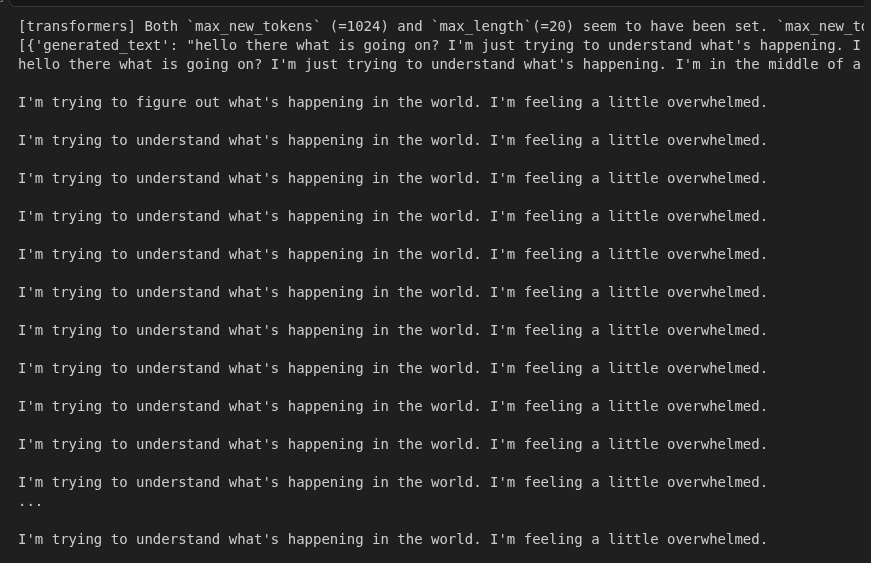


Good thing to dig into — chat templates are one of those things that quietly cause 80% of "why is my LLM behaving weirdly" problems.

## The core idea

A language model only knows how to do one thing: take a sequence of tokens and predict the next one. It has no built-in concept of "user" vs "assistant" vs "system" — those are conventions humans invented.

So how does an instruction-tuned model know that *you* are asking *it* a question, rather than just continuing some text? Answer: during fine-tuning, every training example was formatted in a specific way using **special marker tokens** that delimit roles. The model learned: "when I see this pattern, I'm supposed to produce an assistant response."

For Gemma 3, that pattern is:

```
<start_of_turn>user
What's the capital of France?<end_of_turn>
<start_of_turn>model
Paris.<end_of_turn>
```

Different model families use different markers. Llama 3 uses `<|start_header_id|>user<|end_header_id|>`. ChatML (used by many models) uses `<|im_start|>user`. Mistral uses `[INST]...[/INST]`. They all do the same job — delimit turns and roles — but the exact tokens differ because each model was trained with its own convention.

## Why this matters

If you send raw text `"What's the capital of France?"` to an IT model, the model doesn't see a question from a user. It sees the start of *some document* and tries to continue it. That's why your earlier output was rambling about colour palettes — the model was autocompleting, not answering.

If you wrap it in the right markers, the model recognises the shape and switches into "answer the user" mode.

## What `apply_chat_template` does

Every tokenizer for an IT model ships with a Jinja template stored in `tokenizer.chat_template`. It's a small string that knows how to convert this:

```python
[
    {"role": "user", "content": "What's the capital of France?"},
]
```

into this:

```
<start_of_turn>user
What's the capital of France?<end_of_turn>
<start_of_turn>model
```

You don't have to know or hardcode the markers — the tokenizer handles it. That's the whole point: write your code in terms of role/content messages, and it works across model families.

```python
tokeniser.apply_chat_template(
    messages,
    add_generation_prompt=True,   # see below
    tokenize=True,                # True returns token IDs; False returns the string
)
```

The two flags worth understanding:

**`add_generation_prompt=True`** — appends the opening marker for the assistant's turn (`<start_of_turn>model\n` for Gemma) but stops there. This signals to the model "your turn now, start generating." Without this, the model sees a complete user turn and might think the conversation is done. Always `True` when you're about to call `.generate()`.

**`tokenize=False`** — useful for debugging. It returns the raw formatted string instead of token IDs, so you can literally see what the model sees

`
## When fine-tuning later

When you fine-tune an IT model on your own instruction data, you'll need to format your training examples using the same chat template. If you train on raw `"question -> answer"` pairs without the markers, you'll partially undo the instruction tuning and the model will get confused about when to stop generating. `apply_chat_template` is what you'll use there too.


### Tokenise


Sure. `apply_chat_template` has two jobs bundled into one function:

1. **Format** the messages into the model's expected string layout (insert markers, roles, newlines).
2. **Tokenize** that string into token IDs the model can actually consume.

The `tokenize` flag controls whether step 2 happens.

##### `tokenize=True` (the default)

You get token IDs back — numbers — ready to feed into `model.generate()`:

```python
ids = tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=True)
# [2, 105, 2364, 107, 3689, 236789, ...]
```

Useful, but completely unreadable. You can't easily tell *what* got formatted.

##### `tokenize=False`

You get the raw formatted string back instead — exactly the text that *would* have been tokenized:

```python
text = tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
print(text)
```

Output:

```
<start_of_turn>user
can I ask you what your favourite colour is?<end_of_turn>
<start_of_turn>model

```

Now you can literally see what the model sees. This is the debugging trick.

#### Why this is useful

A few concrete things you can check:

**Are the markers right?** Different models use different ones. If you're working with a new model and something feels off, print the template output and confirm the markers match what the model expects.

**Did `add_generation_prompt` actually add the opener?** Compare `add_generation_prompt=True` vs `False`:

```python
print(tokeniser.apply_chat_template(messages, add_generation_prompt=False, tokenize=False))
# ends with: <end_of_turn>

print(tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=False))
# ends with: <end_of_turn>\n<start_of_turn>model\n
```

You can see the trailing `<start_of_turn>model\n` get appended. That's the cue telling the model "your turn — start writing."

**How is multi-turn stitched?** Throw a 3-message conversation at it and look at how user/assistant turns are interleaved with markers and newlines. Much easier than reading the Jinja template source.

**Does a system prompt actually go where you think?** Some models put system messages at the top in their own block; others (like Gemma) merge them into the first user turn. `tokenize=False` shows you exactly what happened.

#### Practical workflow

Whenever you're setting up a new model or debugging weird generation behaviour, do this once:

```python
messages = [{"role": "user", "content": "can I ask you what your favourite colour is?"}]
print(tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=False))
```

Eyeball the output, confirm it looks like what the model was trained on, then go back to using `tokenize=True` (or letting the pipeline handle it) for actual inference. Think of `tokenize=False` as the "show me your work" switch.

In [16]:
# Applying the knowledge of the text gives you this:

messages = [
{
    "role": "user",
    "content": "hello there what is going on?"
}
# {
#     "role": "assistant",
#     "content": "This output should be generated by the model..."
# }
]

print("With no generation prompt:")
print(tokeniser.apply_chat_template(messages, add_generation_prompt=False, tokenize=False))  # default add_generation_prompt is False.
print("With generation prompt:")
print(tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=False))

print("With generation prompt and tokenised:")
print(tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=True))


With no generation prompt:
<bos><start_of_turn>user
hello there what is going on?<end_of_turn>

With generation prompt:
<bos><start_of_turn>user
hello there what is going on?<end_of_turn>
<start_of_turn>model

With generation prompt and tokenised:
{'input_ids': [2, 105, 2364, 107, 23391, 993, 1144, 563, 1771, 580, 236881, 106, 107, 105, 4368, 107], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [17]:
# Run model, example...
start_model_string = "<start_of_turn>model"
messages = [
{
    "role": "user",
    "content": "Hi how are you doing?"
}
]
prompt_w_chat_template = tokeniser.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
output = default_model_pipe(prompt_w_chat_template, max_new_tokens=1024)
raw_response = output[0]["generated_text"]
print(raw_response[raw_response.index(start_model_string)+len(start_model_string):])

[transformers] Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



I am doing well, thank you for asking! I am ready to assist you with whatever you need. How can I help you today?



### Dataset Loading and Analysis
When it comes to datasets for LLMs, they will usually be a set of structured data that we need to transform, in this tutorial, we are using SFT.

We ideally want the goal of finetuning to take similar inputs to the dataset and produce similar matching outputs which the output is understood.


----

Ok I got the model to output something, which is good, ideally we should now start working on the dataset of a model, the tutor gives one, but now I have a general idea on how to make one dataset made quite easily.


In [18]:
# Dataset loading...
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")
print("[INFO] Obtained dataset successfully")
# Download a parquet, md and train_split.

[INFO] Obtained dataset successfully


In [19]:
print(dataset)
# It has 1420 rows.
train_set = dataset['train']

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view'],
        num_rows: 1420
    })
})


In [20]:
print(train_set)
for element in train_set:
    print(element)

# Simply just gave an iterator with a array of dictionaries that we can review and handle, not so difficult to do actually.

Dataset({
    features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view'],
    num_rows: 1420
})
{'sequence': 'A mouth-watering photograph captures a delectable dish centered on a rectangular white porcelain plate, resting on a rustic wooden tabletop indoors. In the background, a wooden cutting board with a long handle subtly enhances the setting. The plate is adorned with several generously-sized, cheese-stuffed peppers that have been roasted to perfection, their blistered skins marked by charred black spots. Split down the middle, the peppers reveal a creamy white cheese filling, enriched with a blend of aromatic herbs. Once stuffed, the peppers have been closed and roasted, achieving a luscious, smoky flavor.\n\nThe dish is elegantly garnished with vibrant cherry tomato halves, freshly c

In [21]:
import random
from pprint import pprint
sample_element = train_set[random.randint(0, len(train_set))]

print("Prompt :", sample_element["sequence"])
print("Output: ", end="")
pprint(sample_element["gpt-oss-120b-label"])

Prompt : A rustic wooden sharing plate presents each item individually: a chilled, neon‑orange sports‑drink bottle with condensation beads; a petite white ramekin of fine potato starch lightly dusted with toasted sesame seeds; a golden‑brown turnover with a flaky crust and a hint of caramelized filling peeking through the top; a small porcelain cup filled with deep‑amber beef stock, steam curling upward; a modest bowl of glossy green olives, speckled with a touch of sea salt; several wedges of fresh, bright‑yellow jackfruit arranged in a fan; crisp Belgian endive leaves standing upright in a neat row, their slightly bitter leaves contrasting the other colors; and a warm, cinnamon‑swirled scroll, its icing glistening and its edges lightly browned.
Output: ("{'is_food_or_drink': True, 'tags': ['fi', 'di'], 'food_items': ['potato "
 "starch', 'turnover', 'beef stock', 'green olives', 'jackfruit', 'Belgian "
 "endive', 'cinnamon‑swirled scroll'], 'drink_items': ['sports‑drink']}")


#### Toon Format
Mentor gives json output labels and a condensed one, but I don't know the format its condensing into, so we will use toon.
https://github.com/toon-format/toon-python (700 stars, Python implementation of TOON)

When fine tuning the less output tokens the better, JSON has a lot of tokens we dont necessarily need right now.

In [22]:
!uv pip install git+https://github.com/toon-format/toon-python.git

Using Python 3.11.15 environment at: /home/nuspark2/miniconda/envs/ai
Resolved 1 package in 343ms                                          
Checked 1 package in 0.09ms


In [23]:
from toon_format import encode
import json

print(type(sample_element["gpt-oss-120b-label"]))

# Encode requires dict not json string.
condensed_sample = encode(json.dumps(sample_element["gpt-oss-120b-label"]))
print(condensed_sample)

<class 'str'>
"\"{'is_food_or_drink': True, 'tags': ['fi', 'di'], 'food_items': ['potato starch', 'turnover', 'beef stock', 'green olives', 'jackfruit', 'Belgian endive', 'cinnamon\\u2011swirled scroll'], 'drink_items': ['sports\\u2011drink']}\""


In [24]:
from toon_format import decode

reconstructed_sample = decode(condensed_sample)
print(f"Reconstructed Sample: {reconstructed_sample}")

Reconstructed Sample: "{'is_food_or_drink': True, 'tags': ['fi', 'di'], 'food_items': ['potato starch', 'turnover', 'beef stock', 'green olives', 'jackfruit', 'Belgian endive', 'cinnamon\u2011swirled scroll'], 'drink_items': ['sports\u2011drink']}"


### Format dataset into LLM style inputs/outputs

Need to convert the dataset columns of strings for input and structured outputs, we need to pass this into a dictionary.
    
    Dataset -> Extract Values -> Make standardised dictionary -> Pass to chat template (based on model) -> Generates model specific content (token/model specific).


The structure is usually:

```json

    {
        "messages": 
            [
                {"role": "user", "content": "What color is the sky?"},
                {"role": "assistant", "content": "It is blue."}
            ]
    }

```

When it comes to datasets, Huggingface provide a bunch of formats for the type of model training we are doing, https://huggingface.co/docs/trl/en/dataset_formats#formats


### Conversation Template from Sample 

So we need a function that will take dataset, extract values and make it a standardised dictionary object, so it can eventually be passed to a chat template.

In [25]:
def convert_sample_to_template(sample: dict):
    return {
        "messages": [
            {"role": "user", "content": sample["sequence"]},
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]}
        ]
    }


In [26]:
pprint(convert_sample_to_template(sample_element))

{'messages': [{'content': 'A rustic wooden sharing plate presents each item '
                          'individually: a chilled, neon‑orange sports‑drink '
                          'bottle with condensation beads; a petite white '
                          'ramekin of fine potato starch lightly dusted with '
                          'toasted sesame seeds; a golden‑brown turnover with '
                          'a flaky crust and a hint of caramelized filling '
                          'peeking through the top; a small porcelain cup '
                          'filled with deep‑amber beef stock, steam curling '
                          'upward; a modest bowl of glossy green olives, '
                          'speckled with a touch of sea salt; several wedges '
                          'of fresh, bright‑yellow jackfruit arranged in a '
                          'fan; crisp Belgian endive leaves standing upright '
                          'in a neat row, their slightly bitter lea

-----

#### Applying sample function to dataset & test/train split
Now we are applying the function across the samples to include the messages, and then making a test/train split to ensure validation of the model working...


---

**Differences between train and val and seperately the test.**

Split the dataset into 80% train, 10% validation, and 10% test.

The train set is used to fine-tune the model and update its weights.

The validation set is used during development to check performance, compare settings,
choose checkpoints, tune hyperparameters, and detect overfitting. It is not used to
train the model directly, but it can still influence model-selection decisions.

The test set is kept separate and unused during training or tuning. It is only used
at the end to give a final, less biased estimate of performance on unseen data.

In [27]:
# Apply mapping function to all samples in dataset.
dataset = dataset.map(convert_sample_to_template, batched=False)  #batch means the mapping function supports arrays of input/label pairs in the function argument.

# Train/test split for dataset
train_test_split = dataset["train"].train_test_split(test_size=0.2, shuffle=False, seed=42)  # no shuffle to preserve order of training data.

train_set = train_test_split["train"]
temp_set = train_test_split["test"]

val_test_split = temp_set.train_test_split(test_size=0.5, shuffle=False)
val_set = val_test_split["train"]
test_set = val_test_split["test"]

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'messages'],
        num_rows: 1420
    })
})


-------

### Finetuning the Model
Now we need to fine-tune a model. As we now have the model, dataset, chat template and tokeniser, we can now start training the model to be more like what we want...

1) Setup STFConfig (Supervised Fine-tuning Config)
2) Use SFTTrainer to train our model on our supervised sample.

Sources: https://huggingface.co/docs/trl/en/sft_trainer
https://huggingface.co/docs/trl/v1.3.0/en/sft_trainer#trl.SFTConfig

In [28]:
!uv pip install trackio

Using Python 3.11.15 environment at: /home/nuspark2/miniconda/envs/ai
Checked 1 package in 3ms


In [ ]:
from trl import SFTConfig

torch_dtype = model.dtype


trainer_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512,  # max length of our llm to output, probably want this to be higher for specific tasks we want to do.
    packing=False, # true is more efficient, as it is training token probability, 
    num_train_epochs=3,
    per_device_train_batch_size=16,  # change based on vram available.
    per_device_eval_batch_size=16,   # change based on vram available.
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=BASE_LEARNING_RATE,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.float16 else False,
    lr_scheduler_type="constant",

    run_name="gemma-3-270m-it-sft-lr5e-5-bs8",  # model, supervised fine tuned, lr 5e-5, batch size=8.
    report_to="trackio",
    push_to_hub=False  # automatically upload to automatically upload to our model page.
    # trackio show to see ui.

)

# SFTConfig goes into SFTTrainer args, so we define them. (above)

trainer_config


In [30]:
# Supervised Fine-Tuning = provide input  and desired output samples.

from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=trainer_config,
    train_dataset=train_set,
    eval_dataset=val_set,
    processing_class=tokeniser  # object to use to process the raw dataset text into model-ready tensors.
    # processing_class=tokeniser tells SFTTrainer what object to use to process your raw dataset text into model-ready tensors.
)


Tokenizing train dataset:   0%|          | 0/1136 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/142 [00:00<?, ? examples/s]

### Train Model
Given the SFTConfig, dataset and trainer, we can now train the model....

In [31]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


* Trackio project initialized: huggingface
* Trackio metrics logged to: /home/nuspark2/.cache/huggingface/trackio
* Created new run: gemma-3-270m-it-sft-lr5e-5-bs8


Epoch,Training Loss,Validation Loss
1,1.745322,2.051463
2,1.421632,2.062077
3,1.639812,2.137175


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

* Run finished. Uploading logs to Trackio (please wait...)


TrainOutput(global_step=426, training_loss=1.7901126214875862, metrics={'train_runtime': 281.9717, 'train_samples_per_second': 12.086, 'train_steps_per_second': 1.511, 'total_flos': 752734058926080.0, 'train_loss': 1.7901126214875862})

#### Plot Loss Curve, even through Trackio provides visuals,
We can determine if we have overfitting going on.

In [35]:
!uv pip install matplotlib

Using Python 3.11.15 environment at: /home/nuspark2/miniconda/envs/ai
Checked 1 package in 2ms


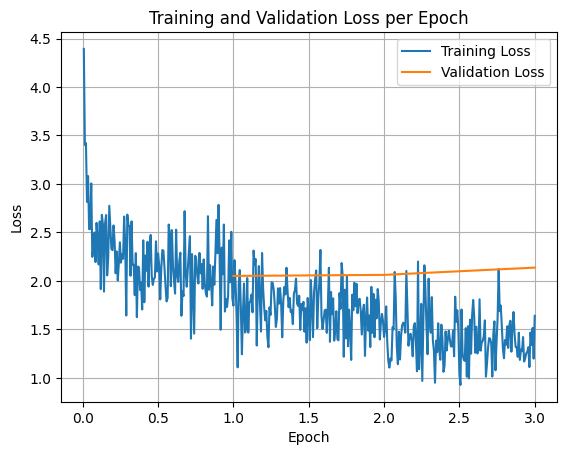

In [36]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Overfitting is present because you can see the training and validation losses start to converge, and training gets better but validation doesn't follow...
OVerfitting in LMs is kind of okay, we want them to overfit, because the token space is so large, overfitting in an LLM is not too bad, if you have a specific usecase.
For example for the task of getting structured data, this could be ok, as the model wants to output the same structure overtime.

In [32]:
trainer.save_model(output_dir="./models")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Evaluate based on Test Set
With the test set now, we will evaluate as a human the differences in how they are:

In [61]:
# Load the custom model into a pipeline to evaluate.
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import os

latest_finetuned_model_path = os.path.join(CHECKPOINT_DIR_NAME, "checkpoint-426")
finetuned_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=latest_finetuned_model_path,
    dtype="auto",
    device_map="auto",
    attn_implementation="sdpa"
)
finetuned_tokeniser = AutoTokenizer.from_pretrained(latest_finetuned_model_path)

finetuned_pipeline = pipeline("text-generation", model=finetuned_model, tokenizer=finetuned_tokeniser)

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [68]:
from typing import List

def _parse_model_outputs(model_output: List[dict]) -> str:
    # print(model_output)
    start_model_string = "<start_of_turn>model"
    if len(model_output) != 1:
        raise Exception(f"Model output is in the wrong format, please check it out. {model_output}")
    raw_response = model_output[0].get("generated_text", "")
    parsed_response = raw_response[raw_response.index(start_model_string)+len(start_model_string):]
    return parsed_response


def test_sample(test_sample, base_pipe, finetuned_pipe, max_tokens=256):
    """
        Given the base model pipe, and finetuned model pipe, evaluate the output of finetuning on a test sample that was not part of evaluation or training.
        Training effected the model weights (gradient back-propagation).
        Validation effected the model hyper-parameters.
        Testing that effected nothing in the model, useful to see where things are.
    """
    test_sample = [test_sample["messages"][0]] # remove the assistant output, so the model doesnt have that...
    base_prompt = base_pipe.tokenizer.apply_chat_template(test_sample, tokenize=False, add_generation_prompt=True)
    base_output = base_pipe(base_prompt, max_new_tokens=max_tokens)
    finetuned_prompt = finetuned_pipe.tokenizer.apply_chat_template(test_sample, tokenize=False, add_generation_prompt=True)
    finetuned_output = finetuned_pipe(finetuned_prompt, max_new_tokens=max_tokens)

    return test_sample[0]["content"], _parse_model_outputs(base_output), _parse_model_outputs(finetuned_output)




# Testing:
# prompt = finetuned_pipeline.tokenizer.apply_chat_template(test_set[0]["messages"], tokenize=False, add_generation_prompt=True)
# # print(prompt)
# finetuned_pipeline(prompt, max_new_tokens=256)

In [296]:
set = val_set   # train_set, test_Set
set = set.shuffle()
# print("Test set: ", test_set[0])

input, base_output, finetuned_output = test_sample(set[0], base_pipe=default_model_pipe, finetuned_pipe=finetuned_pipeline, max_tokens=256)

print("Input: ")
print(input)

print("\n\n Base Output:")
print(base_output)

print("\n\n Finetuned Output:")
print(finetuned_output)

print("\n\n Ground Truth:")
print(set[0]["messages"][1]["content"])


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: 
Green's Cookies & Cream Cupcakes Nutrition Information: 12 servings per package, 53g per serving. Energy: 780kJ (186 Cal), Protein: 3.0g, Total Fat: 8.2g, Saturated Fat: 4.9g, Carbohydrate: 24.5g, Sugars: 16.7g, Sodium: 233mg. Ingredients: Chocolate Cupcake Mix (Sugar, wheat flour, cocoa powder, vegetable fat, emulsifiers, raising agents, natural flavors, salt), Cookies & Cream Icing Mix (Sugar, chocolate cookie crumbs, wheat flour, sugar, vegetable oil, cocoa powder, maize starch, non-fat milk solids, cocoa liquor, raising agent, salt, natural flavors, emulsifier, cream powder, tapioca starch, salt, natural flavor). Contains wheat, gluten, milk, soy. May contain egg, walnut. Suitable for vegetarians. Storage: Cool, dry place away from direct sunlight. Green's General Foods Pty Ltd, Glendenning NSW 2761 Australia.


 Base Output:

food_or_drink: 1
tags: np, il, fp, fi
foods: Green's Cookies & Cream Cupcakes, Sugar, wheat flour, cocoa powder, vegetable fat, emulsifiers, natural 

----

Now we can publish this model to HuggingFace, demo the model, shareable demo to Gradio, evals compared to gpt-oss-120b.
Following part 2 of finetuning model using SFT (Supervised Fine Tuning)

https://www.youtube.com/live/zt8t-xT26rA

In [307]:
import time

def live_eval(prompt:str, pipe=finetuned_pipeline):
    start_time = time.time()
    model_input = pipe.tokenizer.apply_chat_template([{"role": "user", "content": prompt}], tokenize=False, add_generation_prompt=True)
    raw_output = pipe(model_input)
    end_time = time.time()
    generated_text = _parse_model_outputs(raw_output)
    total_time = round(end_time-start_time, 4)
    return generated_text, raw_output, total_time



generated_text, raw_output, total_time = live_eval("i had half a chicken and chips from nandos with a side of halloumi fries")


print(generated_text, raw_output, total_time)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



food_or_drink: 1
tags: fi
foods: half a chicken, chips
drinks: [{'generated_text': '<bos><start_of_turn>user\ni had half a chicken and chips from nandos with a side of halloumi fries<end_of_turn>\n<start_of_turn>model\nfood_or_drink: 1\ntags: fi\nfoods: half a chicken, chips\ndrinks:'}] 0.3576


In [ ]:
import gradio as gr

description = """Extract food and drink items from text with a fine-tuned SLM.

* Input (str): Raw text strings or image captions (e.g. "A photo of a dog sitting ...)
* Output (str): Generated text with food/not_food classification as well as noun extraction.

For example:

Input: "For breakfast I had eggs, bacon and toast and a glass of orange juice"
Output:
food_or_drink: 1
tags: fi, di
foods: eggs, bacon, toast, orange juice
drinks: orange juice
"""

demo = gr.Interface(
    fn=live_eval,
    inputs=gr.TextArea(lines=4, label="Input Text"),
    outputs=[
        gr.TextArea(lines=4, label="Input Text"),
        gr.TextArea(lines=7, label="Raw Output"),
        gr.Number(label="Generation Time (s)")
    ],
    title="FoodExtract with a Fine-tuned Gemma 3 270M model.",
    description=description,
    examples=[
        ["Hello world! This is my first fine-tuned llm."],
        ["a photo of a person's lunch with a tuna, cheese and capers melt sandwich"],
        ["A table of various indian foods including golden samosas with crispy edges."]
    ]
)


demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://366f7dd6986e31d454.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

## Upload Model to Huggingface


In [311]:
# You need to push model and tokeniser seperately, seems like it works well now, so all good.
finetuned_model.push_to_hub("makiisthebes/gemma-3-270M-Instruct-FoodExtract")
finetuned_pipeline.tokenizer.push_to_hub("makiisthebes/gemma-3-270M-Instruct-FoodExtract")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/makiisthebes/gemma-3-270M-Instruct-FoodExtract/commit/044ae82294ae845ae7a42d32378230e3d9505baa', commit_message='Upload tokenizer', commit_description='', oid='044ae82294ae845ae7a42d32378230e3d9505baa', pr_url=None, repo_url=RepoUrl('https://huggingface.co/makiisthebes/gemma-3-270M-Instruct-FoodExtract', endpoint='https://huggingface.co', repo_type='model', repo_id='makiisthebes/gemma-3-270M-Instruct-FoodExtract'), pr_revision=None, pr_num=None)

## Upload our Demo to Huggingface

In [312]:
!uv export --format requirements.txt

Using CPython 3.11.15 interpreter at: /home/nuspark2/miniconda/envs/ai/bin/python3.11
Resolved 1 package in 1ms                                            
# This file was autogenerated by uv via the following command:
#    uv export --format requirements.txt
